In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from natsort import natsorted

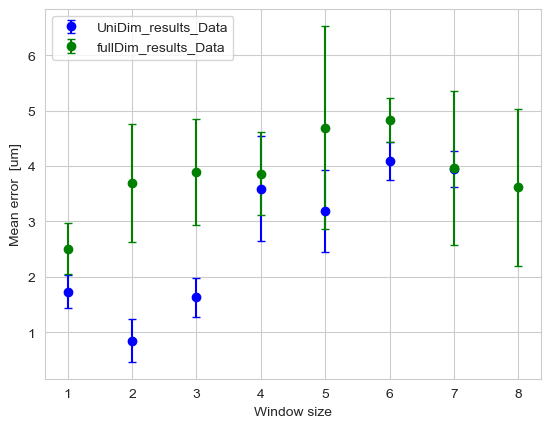

In [9]:
error = []
mean = []
window = []
colour =['b','g','r','c','m','y','k']

for col, file in enumerate(['UniDim_results_Data', 'fullDim_results_Data']):
    LSTM_Data_Dir = Path.joinpath(Path(os.getcwd()), file)
    
    x = []
    y = []
    diff = 0
    mean = []
    error = []
    window = []
    
    for I, cell in enumerate(LSTM_Data_Dir.iterdir()):
    
        data = np.genfromtxt(cell, delimiter=',', skip_header=1)
        
        x = data[:,1]-data[:,3]
        y = data[:,2]-data[:,4]
        
        diff = .180*(x**2 + y**2)**.5
        
        window.append(I + 1)
        mean.append(np.mean(diff[-3:]))
        error.append(np.std(diff[-3:]))

    plt.errorbar(window, mean, yerr=error, fmt='o', color=colour[col], capsize=3)
            
plt.xlabel('Window size')
plt.ylabel('Mean error  [um]')
plt.legend(['UniDim_results_Data', 'fullDim_results_Data'])
plt.show()

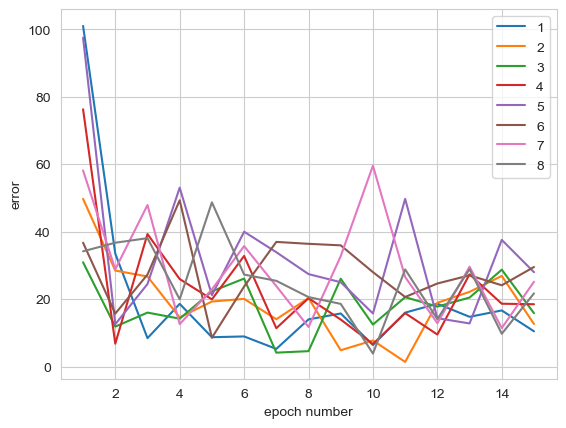

In [32]:
window = []
for I, cell in enumerate(LSTM_Data_Dir.iterdir()):

    data = np.genfromtxt(cell, delimiter=',', skip_header=1)

    x = data[:,1]-data[:,3]
    y = data[:,2]-data[:,4]
    
    diff = (x**2 + y**2)**.5

    window.append(I + 1)
    plt.plot(data[:,0], diff)
    
plt.xlabel('epoch number')
plt.ylabel('error')
plt.legend([win for win in  window])
plt.show()